In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import price_option_bsm

seed = 42

In [2]:
np.random.seed(42)

In [3]:
x0, y0 = 0.5, 0.5
x = np.random.uniform(0,1,100000)
y = np.random.uniform(0,1,100000)

In [4]:
(np.sqrt((x-0.5)**2 + (y-0.5)**2)<0.5).sum()/100000*4

np.float64(3.14412)

In [21]:
def simulate_terminal_prices(s, r, sigma, T, q, n_paths=1000, seed=None):

    if seed is not None:
        np.random.seed(seed)
    
    np.random.seed(seed)
    z = np.random.normal(0, 1, n_paths)
    s1 = s*np.exp((r-q-0.5*sigma**2)*T + sigma*np.sqrt(T)*z)
    return s1

def simulate_option_payoff(option_type, exercise_style, s, k, r, sigma, T, q, n_paths):

    s_final = simulate_terminal_prices(s, r, sigma, T, q, n_paths)
    if option_type=='call':
        return np.maximum(s_final - k, 0)
    elif option_type=='put':
        return np.maximum(k - s_final, 0)
    else:
        return ValueError("option type must be call or put")

Monte Carlo price: 52.752507741397785
BSM price: 52.78253555118326
Std error: 0.24979508100282782
95% CI: (np.float64(52.262909382632245), np.float64(53.242106100163326))


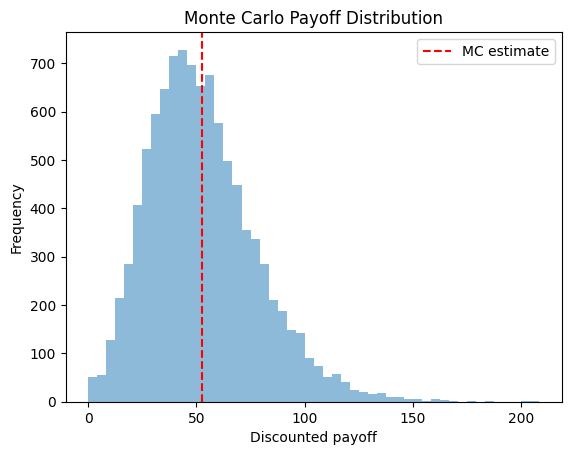

In [20]:
# parameters
s = 100
k = 50
r = 0.1
sigma = 0.25
T = 1
q = 0.02

option_type = 'call'
exercise_style = 'European'

n_paths = 10000
payoffs = simulate_option_payoff(option_type, exercise_style, s, k, r, sigma, T, q, n_paths)
discounted_payoffs = np.exp(-r*T)*payoffs

value = np.mean(discounted_payoffs)
std_error = np.std(discounted_payoffs)/np.sqrt(n_paths)
ci_low = value - 1.96 * std_error
ci_high = value + 1.96 * std_error
price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)

print("Monte Carlo price:", value)
print("BSM price:", price_bsm)
print("Std error:", std_error)
print("95% CI:", (ci_low, ci_high))

plt.hist(discounted_payoffs, bins=50, alpha=0.5)
plt.axvline(value, linestyle='--', color='red', label='MC estimate')
#plt.axvline(price_bsm, linestyle='--', color='orange', label='BSM price')

plt.title("Monte Carlo Payoff Distribution")
plt.xlabel("Discounted payoff")
plt.ylabel("Frequency")

plt.legend()
plt.show()